# Bagging y Random Forest: combinar árboles en paralelo

> Cómo promediar muchos árboles entrenados con muestras *bootstrap* reduce la varianza de un árbol solo, qué añade Random Forest (elegir al azar las variables candidatas en cada corte), cómo estimar el error sin conjunto de validación (*out-of-bag*) y dónde falla (extrapolación, clases raras, importancias sesgadas).
>
> **Requisitos previos:** [Árboles de decisión](08-arboles-decision.ipynb) · **Relacionado:** [Flujo de ML y evaluación](01-flujo-ml-y-evaluacion.ipynb) · [selección de atributos](03-seleccion-atributos.ipynb) · [boosting](11-boosting.ipynb) · [stacking y cascading](12-stacking-y-cascading.ipynb) · [interpretabilidad](14-interpretabilidad.ipynb)

## 1. Idea clave

Un [árbol de decisión](08-arboles-decision.ipynb) profundo tiene poco sesgo pero mucha **varianza**: un cambio pequeño en los datos produce un árbol distinto. La **combinación de modelos** (*ensemble learning*) aprovecha eso: si entrenamos muchos árboles sobre versiones ligeramente distintas de los datos y **promediamos** sus predicciones, los errores aleatorios de cada uno se compensan.

**Bagging** (*bootstrap aggregating*) genera esas versiones remuestreando con reemplazo; **Random Forest** (bosque aleatorio) añade un segundo ingrediente de azar, limitar las variables entre las que cada corte puede elegir, para que los árboles se parezcan menos entre sí. El resultado suele ser una primera opción muy sólida en datos tabulares: apenas necesita preparación (no hay que escalar), ajusta bien con parámetros por defecto, admite relaciones no lineales e interacciones y da gratis una estimación del error (*out-of-bag*). A cambio, se pierde la lectura del árbol como reglas, no extrapola y ocupa más memoria y tiempo que un árbol.

## 2. Conceptos importantes

### 2.1. Intuición: la sabiduría de la multitud

Un solo árbol profundo es un experto que ha memorizado sus datos y se equivoca de formas idiosincrásicas. Si le pedimos opinión a cien expertos que han visto muestras distintas y **cuyos errores no están todos en el mismo sitio**, la decisión por mayoría suele ser mejor que la de cualquiera. Dos condiciones lo hacen funcionar: cada modelo debe ser **mejor que el azar** y los errores de unos modelos y otros deben ser **poco correlacionados**.

### 2.2. *Bootstrap*: muestras con reemplazo

Una muestra *bootstrap* de un conjunto de $n$ ejemplos se obtiene sacando $n$ ejemplos **con reemplazo**: algunos aparecen varias veces y otros ninguna. La probabilidad de que un ejemplo concreto **no** salga en ninguna de las $n$ extracciones es

$$
\left(1 - \frac{1}{n}\right)^{n} \xrightarrow[n \to \infty]{} e^{-1} \approx 0{,}368
$$

Así, cada muestra contiene ≈ 63,2 % de ejemplos distintos, y el ≈ 36,8 % restante queda **fuera de la bolsa** (*out-of-bag*, OOB) de ese árbol.

### 2.3. Bagging

Se entrenan $B$ modelos $\hat f_1, \dots, \hat f_B$, cada uno con su muestra *bootstrap*, y se combinan:

$$
\hat f_{\text{bag}}(x) = \frac{1}{B} \sum_{b=1}^{B} \hat f_b(x) \quad \text{(regresión)}
\qquad\qquad
\hat y(x) = \text{moda}\{\hat f_b(x)\}_{b=1}^{B} \quad \text{(clasificación, voto mayoritario)}
$$

(scikit-learn, en lugar de contar votos, promedia las probabilidades que da cada árbol y elige la clase con mayor probabilidad media.) Los árboles de un bagging **se pueden entrenar en paralelo**, porque no dependen unos de otros; es lo que lo distingue del [boosting](11-boosting.ipynb), que los entrena en secuencia.

### 2.4. Por qué reduce la varianza (y qué límite tiene)

Si cada modelo tiene varianza $\sigma^2$ y la correlación entre las predicciones de dos modelos cualesquiera es $\rho$, la varianza del promedio de $B$ modelos es

$$
\operatorname{Var}\big(\hat f_{\text{bag}}\big) = \rho\,\sigma^{2} + \frac{1 - \rho}{B}\,\sigma^{2}
$$

Añadir árboles ($B \to \infty$) hace desaparecer el segundo término, pero **el primero, $\rho\sigma^2$, no baja**: lo que queda depende de cuánto se parecen los árboles. Dos consecuencias:

- **Más árboles nunca perjudican**: la mejora se satura, no se invierte. $B$ solo cuesta tiempo y memoria.
- Para bajar más hay que **decorrelacionar** los árboles. Eso es lo que añade Random Forest.

El **sesgo** del promedio es el de un árbol individual, así que el bagging funciona con árboles **profundos** (poco sesgo, mucha varianza) y no ayuda a modelos ya estables.

### 2.5. Random Forest

Es un bagging de árboles con un cambio en el crecimiento de cada árbol: **en cada nodo, el corte se busca solo entre $m'$ variables elegidas al azar** de las $m$ disponibles (no una vez por árbol, sino en cada corte). Valores habituales: $m' = \sqrt{m}$ en clasificación (el valor por defecto de scikit-learn) y todas las variables en regresión.

Sin esa restricción, si hay una variable muy predictiva, todos los árboles la usan en la raíz y se parecen mucho ($\rho$ alta). Con ella, algunos árboles tienen que partir por otras variables, la correlación baja y el promedio mejora. El precio es que cada árbol individual es algo peor.

Resumiendo el algoritmo: para $b = 1, \dots, B$, (1) tomar una muestra *bootstrap* de los datos; (2) hacer crecer un árbol sin podar, eligiendo en cada nodo el mejor corte entre $m'$ variables al azar; y devolver el conjunto de árboles, que se promedian al predecir.

### 2.6. Error *out-of-bag*

Cada ejemplo queda fuera de la muestra de ≈ 37 % de los árboles. Para cada ejemplo se promedian **solo** las predicciones de los árboles que no lo vieron y se compara con su etiqueta real; la tasa de error global es el **error OOB**. Es casi una validación cruzada gratuita: no hace falta apartar datos ni reentrenar. Requiere suficientes árboles para que todos los ejemplos tengan predicciones OOB.

### 2.7. Importancia de las variables

Un bosque da dos medidas: la **importancia por impureza** (cuánto reducen la impureza, en media, los cortes que usan cada variable; se calcula con los datos de entrenamiento) y la **importancia por permutación** (cuánto empeora la métrica al barajar una variable; se puede calcular en test). La primera está sesgada hacia variables con muchos valores distintos; se discute en la sección 3.5 y en [selección de atributos](03-seleccion-atributos.ipynb).

## 3. Código

Usamos **breast cancer** (569 tumores, 30 medidas numéricas, clase maligno/benigno; `load_breast_cancer`, derivado del repositorio UCI) como en los [árboles](08-arboles-decision.ipynb), para comparar con un árbol solo. Además, un conjunto **sintético** con variables de ruido (importancias), otro **desbalanceado**, y `load_diabetes` (442 pacientes, regresión).

In [1]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer, load_diabetes, make_classification
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import f1_score, precision_score, r2_score, recall_score
from sklearn.model_selection import KFold, StratifiedKFold, cross_val_score, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor

### 3.1. Bagging a mano

Separamos un 20 % para test (clase 0 = maligno, 1 = benigno). Primero comprobamos cuántos ejemplos distintos entran en una muestra *bootstrap* y luego construimos un bagging de 25 árboles sin límites a mano: cada uno con su muestra, y la predicción final por mayoría.

In [2]:
X, y = load_breast_cancer(return_X_y=True, as_frame=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

n = len(X_train)
rng = np.random.default_rng(42)
frac_distintos = np.mean([len(np.unique(rng.integers(0, n, n))) / n for _ in range(200)])
print(f"Ejemplos distintos por muestra bootstrap: {frac_distintos:.3f} (teoría: {1 - (1 - 1 / n) ** n:.3f})")

votos = []
for b in range(25):
    idx = rng.integers(0, n, n)  # muestra con reemplazo
    arbol = DecisionTreeClassifier(random_state=b).fit(X_train.iloc[idx], y_train.iloc[idx])
    votos.append(arbol.predict(X_test))
votos = np.array(votos)

exactitud_arboles = (votos == y_test.to_numpy()).mean(axis=1)
exactitud_voto = ((votos.mean(axis=0) > 0.5) == y_test.to_numpy()).mean()
print(f"Exactitud de cada árbol en test: media {exactitud_arboles.mean():.3f} "
      f"(mín {exactitud_arboles.min():.3f}, máx {exactitud_arboles.max():.3f})")
print(f"Exactitud del voto de los 25 árboles: {exactitud_voto:.3f}")

Ejemplos distintos por muestra bootstrap: 0.633 (teoría: 0.633)
Exactitud de cada árbol en test: media 0.917 (mín 0.877, máx 0.965)
Exactitud del voto de los 25 árboles: 0.965


Cada muestra contiene ≈ 63 % de ejemplos distintos, como predice la teoría. Los árboles individuales aciertan entre el 87,7 % y el 96,5 % del test (media 0,917) y el voto de los 25 llega al **0,965**: mucho mejor que la media e igual que el mejor árbol, pero sin haberlo elegido de antemano. Esa es la ganancia del promedio.

### 3.2. Árbol, bagging y Random Forest

Con las clases de scikit-learn y 200 árboles: `BaggingClassifier` (bagging puro, todas las variables en cada corte) y `RandomForestClassifier`. Comparamos con un árbol solo mediante validación cruzada en el entrenamiento y el test.

In [3]:
modelos = {
    "Árbol": DecisionTreeClassifier(random_state=42),
    "Bagging (200 árboles)": BaggingClassifier(DecisionTreeClassifier(), n_estimators=200, random_state=42, n_jobs=-1),
    "Random Forest (200 árboles)": RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
}
filas = {}
for nombre, modelo in modelos.items():
    puntuaciones = cross_val_score(modelo, X_train, y_train, cv=cv)
    filas[nombre] = {"CV media": puntuaciones.mean(), "CV std": puntuaciones.std(),
                     "test": modelo.fit(X_train, y_train).score(X_test, y_test)}
pd.DataFrame(filas).T.round(3)

,CV media,CV std,test
Árbol,0.916,0.018,0.912
Bagging (200 árboles),0.952,0.022,0.947
Random Forest (200 árboles),0.963,0.018,0.956


Pasar de un árbol a un bosque sube la validación cruzada de 0,916 a ≈ 0,95–0,96. La diferencia entre árbol y conjuntos (≈ 4–5 puntos) supera la desviación entre particiones (≈ 0,02), pero la diferencia entre bagging y Random Forest (≈ 1 punto) **no**: en este conjunto, con 114 casos de test, un ejemplo mueve la exactitud 0,009. Aquí las 30 variables están muy correlacionadas, así que limitar las variables por corte aporta poco; el efecto de `max_features` se ve en 3.4.

### 3.3. Número de árboles y error *out-of-bag*

Entrenamos bosques con 10 a 500 árboles y miramos el error OOB (sin usar el test) junto con el test.

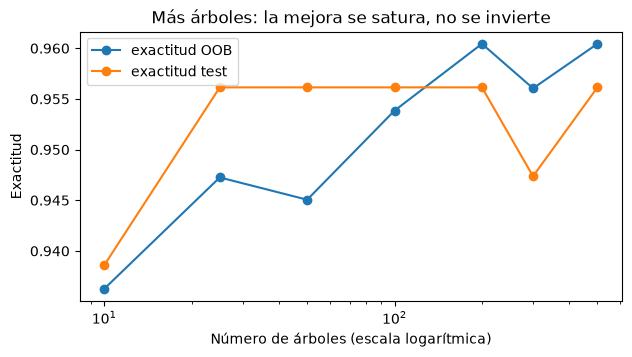

árboles,10,25,50,100,200,300,500
exactitud OOB,0.936,0.947,0.945,0.954,0.960,0.956,0.960
exactitud test,0.939,0.956,0.956,0.956,0.956,0.947,0.956


In [4]:
filas = []
for T in [10, 25, 50, 100, 200, 300, 500]:
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")  # con pocos árboles, algunos ejemplos no tienen predicción OOB
        rf = RandomForestClassifier(n_estimators=T, oob_score=True, random_state=42, n_jobs=-1).fit(X_train, y_train)
    filas.append({"árboles": T, "exactitud OOB": rf.oob_score_, "exactitud test": rf.score(X_test, y_test)})
curva = pd.DataFrame(filas).set_index("árboles")

curva.plot(marker="o", logx=True, figsize=(7, 3.5))
plt.title("Más árboles: la mejora se satura, no se invierte")
plt.xlabel("Número de árboles (escala logarítmica)")
plt.ylabel("Exactitud")
plt.show()
curva.round(3).T

La exactitud OOB sube con los primeros árboles (0,936 con 10) y se estabiliza en ≈ 0,95–0,96 a partir de ~100; pasar de 200 a 500 no cambia nada. El OOB (0,960) coincide con la validación cruzada de 3.2 (0,963) **sin haber apartado ni un ejemplo ni reentrenado cinco veces**. El test oscila entre 0,947 y 0,956 desde 25 árboles: con tan pocos casos (un ejemplo son 0,009) es una medida gruesa.

### 3.4. Decorrelacionar los árboles: `max_features`

La sección 2.4 decía que lo que limita al bagging es la correlación $\rho$ entre árboles. Medimos esa correlación directamente: la media de los coeficientes de correlación entre las probabilidades que dan, sobre el test, cada par de árboles de un bosque de 100, para distintos valores de `max_features` (1 variable por corte, $\sqrt{30} \approx 5$ que es el valor por defecto, 15 y las 30, que equivale a un bagging).

In [5]:
filas = []
for mf in [1, 2, 5, 15, 30]:
    rf = RandomForestClassifier(n_estimators=100, max_features=mf, random_state=42, n_jobs=-1)
    cv_media = cross_val_score(rf, X_train, y_train, cv=cv).mean()
    rf.fit(X_train, y_train)
    P = np.array([t.predict_proba(X_test.to_numpy())[:, 1] for t in rf.estimators_])
    corr = np.corrcoef(P)[np.triu_indices(len(P), k=1)].mean()
    filas.append({"max_features": mf, "correlación media entre árboles": corr, "CV media": cv_media})
pd.DataFrame(filas).set_index("max_features").round(3)

,correlación media entre árboles,CV media
max_features,,
1,0.686,0.960
2,0.746,0.958
5,0.788,0.963
15,0.810,0.960
30,0.806,0.954


La correlación entre árboles **baja de 0,81 (30 variables) a 0,79 (5) y a 0,69 (1)**: restringir las variables candidatas decorrela los árboles, como predice la teoría. Pero la exactitud casi no responde (0,954–0,963, dentro del ruido de la validación cruzada, ≈ 0,02). En un problema con muchas variables correlacionadas o con una variable dominante, el efecto de `max_features` suele pesar más; es uno de los dos parámetros que de verdad conviene ajustar (junto con el tamaño de las hojas).

### 3.5. Importancia de las variables

Reutilizamos el conjunto sintético de los [árboles](08-arboles-decision.ipynb): dos variables útiles y tres de ruido (una binaria, una continua y un identificador aleatorio con muchos valores). Un bosque de 300 árboles; la importancia por permutación se calcula en test.

In [6]:
X_sint, y_sint = make_classification(n_samples=600, n_features=2, n_informative=2, n_redundant=0,
                                     n_clusters_per_class=1, flip_y=0.1, random_state=42)
X_sint = pd.DataFrame(X_sint, columns=["util_1", "util_2"])
rng = np.random.default_rng(42)
X_sint["ruido_binario"] = rng.integers(0, 2, len(X_sint))
X_sint["ruido_continuo"] = rng.normal(size=len(X_sint))
X_sint["id_aleatorio"] = rng.integers(0, 600, len(X_sint))

Xs_train, Xs_test, ys_train, ys_test = train_test_split(X_sint, y_sint, test_size=0.3, stratify=y_sint, random_state=42)
rf_sint = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1).fit(Xs_train, ys_train)
perm = permutation_importance(rf_sint, Xs_test, ys_test, n_repeats=30, random_state=42)

print(f"Exactitud: entrenamiento {rf_sint.score(Xs_train, ys_train):.2f} | test {rf_sint.score(Xs_test, ys_test):.2f}")
pd.DataFrame({"importancia por impureza": rf_sint.feature_importances_,
              "importancia por permutación (test)": perm.importances_mean}, index=X_sint.columns).round(3)

Exactitud: entrenamiento 1.00 | test 0.88


,importancia por impureza,importancia por permutación (test)
util_1,0.164,0.075
util_2,0.625,0.363
ruido_binario,0.011,0.000
ruido_continuo,0.093,-0.004
id_aleatorio,0.107,-0.010


El bosque acierta el 100 % del entrenamiento (los árboles son profundos) y el 88 % del test. La importancia por impureza reparte ≈ 21 % entre las tres variables de ruido (0,107 solo para el identificador aleatorio, casi tanto como una variable útil como `util_1`, 0,164), mientras que la de permutación en test las deja en ≈ 0 y reconoce a `util_2` y `util_1` como las únicas relevantes. Promediar muchos árboles no corrige este sesgo de la impureza.

### 3.6. Regresión

`RandomForestRegressor` promedia los valores de las hojas. Comparamos un árbol y un bosque en `load_diabetes` (progresión de la diabetes a un año, 10 variables) con $R^2$ en validación cruzada.

In [7]:
X_dia, y_dia = load_diabetes(return_X_y=True, as_frame=True)
kf = KFold(n_splits=5, shuffle=True, random_state=42)
regresores = {"Árbol": DecisionTreeRegressor(random_state=42),
              "Random Forest (300 árboles)": RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)}
pd.DataFrame({nombre: {"R² CV media": cross_val_score(m, X_dia, y_dia, cv=kf, scoring="r2").mean()}
              for nombre, m in regresores.items()}).T.round(3)

,R² CV media
Árbol,-0.133
Random Forest (300 árboles),0.427


Un árbol sin límites tiene $R^2 \approx -0{,}13$ (peor que predecir la media), y el bosque ≈ 0,43: en regresión la ganancia por promediar suele ser aún mayor, porque cada árbol profundo es muy ruidoso.

## 4. Parámetros importantes y errores comunes

### 4.1. Parámetros que conviene conocer

| Parámetro | Qué controla | Consejo |
|---|---|---|
| `n_estimators` | Número de árboles $B$ | Más es mejor y se satura (sección 3.3); 200–500 suele bastar. No hace falta meterlo en la rejilla de búsqueda: fíjalo alto |
| `max_features` | Variables candidatas en cada corte $m'$ | `"sqrt"` por defecto en clasificación, `1.0` en regresión. Es el parámetro que más influye en la decorrelación |
| `min_samples_leaf` | Tamaño mínimo de las hojas | Suaviza el bosque, sobre todo en regresión, y reduce el tamaño en memoria |
| `max_depth` | Profundidad máxima | Por defecto sin límite (poco sesgo); limitarla ahorra memoria y tiempo |
| `max_samples` | Tamaño de la muestra *bootstrap* (fracción de $n$) | Valores menores aceleran y decorrelan más; requiere `bootstrap=True` |
| `bootstrap` | Si se muestrea con reemplazo | `False` entrena cada árbol con todos los datos y quita la variación por muestreo (y el OOB) |
| `oob_score` | Calcula la exactitud *out-of-bag* | Estimación gratuita del error (sección 3.3) |
| `class_weight` | Peso por clase | `"balanced"` o `"balanced_subsample"` con clases desbalanceadas |
| `n_jobs` | Árboles en paralelo | `-1` usa todos los núcleos |
| `random_state` | Semilla (muestras y variables) | Fíjala para reproducir resultados |

### 4.2. Errores comunes

**1. Creer que muchos árboles sobreajustan.** No: la varianza del promedio (sección 2.4) deja de bajar, pero no sube. El número de árboles es un compromiso de coste, no un parámetro que ajustar con cuidado. En un caso real, una búsqueda en rejilla con 36 combinaciones y validación cruzada de 5 particiones (180 entrenamientos) incluía `n_estimators` en {100, 200, 500}: casi todo el esfuerzo se gastaba en un parámetro que apenas importaba. Fija `n_estimators` y busca sobre `max_features` y `min_samples_leaf`.

**2. Aplicar bagging a un modelo estable.** El bagging reduce **varianza**; si el modelo base ya es estable (k-NN con pocos vecinos escalados, regresión lineal) no hay mucho que reducir:

In [8]:
knn = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5))
knn_bagging = BaggingClassifier(knn, n_estimators=100, random_state=42, n_jobs=-1)
for nombre, modelo in {"k-NN solo": knn, "Bagging de 100 k-NN": knn_bagging}.items():
    puntuaciones = cross_val_score(modelo, X_train, y_train, cv=cv)
    print(f"{nombre}: CV {puntuaciones.mean():.3f} ± {puntuaciones.std():.3f}")

k-NN solo: CV 0.963 ± 0.011


Bagging de 100 k-NN: CV 0.967 ± 0.010


El bagging de k-NN (0,963 → 0,967) mejora menos de lo que varía la validación cruzada entre particiones (± 0,01) y multiplica el coste por 100. Con árboles, en cambio, la ganancia es clara (3.2).

**3. Fiarse de la importancia por impureza.** Está sesgada hacia variables con muchos valores distintos y reparte importancia entre variables correlacionadas (3.5). Calcula la **importancia por permutación en un conjunto de test** y, si hay variables muy correlacionadas, agrúpalas o interprétalas juntas. Más en [interpretabilidad](14-interpretabilidad.ipynb).

**4. Quedarse con la exactitud con clases desbalanceadas.** Un bosque entrenado con muchos más ejemplos de una clase tiende a predecir la mayoritaria. Aquí, un 5 % de positivos:

In [9]:
X_des, y_des = make_classification(n_samples=10000, n_features=10, n_informative=4, weights=[0.95, 0.05],
                                   flip_y=0.02, class_sep=0.8, random_state=42)
Xd_train, Xd_test, yd_train, yd_test = train_test_split(X_des, y_des, test_size=0.3, stratify=y_des, random_state=42)

configuraciones = {"por defecto": dict(),
                   "class_weight='balanced'": dict(class_weight="balanced"),
                   "balanced + min_samples_leaf=5": dict(class_weight="balanced", min_samples_leaf=5)}
filas = {}
for nombre, params in configuraciones.items():
    pred = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1, **params).fit(Xd_train, yd_train).predict(Xd_test)
    filas[nombre] = {"exactitud": (pred == yd_test).mean(), "sensibilidad (clase rara)": recall_score(yd_test, pred),
                     "precisión (clase rara)": precision_score(yd_test, pred), "F1 macro": f1_score(yd_test, pred, average="macro")}
pd.DataFrame(filas).T.round(3)

,exactitud,sensibilidad (clase rara),precisión (clase rara),F1 macro
por defecto,0.964,0.413,0.961,0.780
class_weight='balanced',0.965,0.486,0.879,0.804
balanced + min_samples_leaf=5,0.953,0.592,0.609,0.788


La exactitud es ≈ 0,95–0,96 en las tres configuraciones, pero **la sensibilidad con la clase rara es solo de 0,41** por defecto: el bosque deja pasar casi 6 de cada 10 casos raros. Con `class_weight="balanced"` sube a 0,49 y con hojas de al menos 5 ejemplos, a 0,59, pero **la precisión cae** (de 0,96 a 0,88 y a 0,61): es un compromiso entre falsas alarmas y casos perdidos, y el F1 macro apenas cambia (0,78, 0,80, 0,79). Elige el equilibrio según el coste de cada error. Mira siempre una métrica por clase (sensibilidad, $F_1$ macro); en un problema real con tres estados de funcionamiento (50 %, 30 % y 20 %) fue la $F_1$ macro, no la exactitud, la que mostró la diferencia entre modelos. Más técnicas en [muestreo y desbalanceo](../03-preparacion-datos/04-muestreo-y-desbalanceo.ipynb).

**5. Esperar que extrapole.** Un bosque promedia valores vistos en entrenamiento, así que fuera de su rango repite el último valor, igual que un [árbol](08-arboles-decision.ipynb). Entrenamos con $x < 6$ sobre $y = 3x + 500$ y evaluamos con $x \ge 6$:

In [10]:
rng = np.random.default_rng(0)
x = np.sort(rng.uniform(0, 10, 250))
y_lin = 3 * x + 500 + rng.normal(0, 3, 250)
visto = x < 6

rf_reg = RandomForestRegressor(n_estimators=200, random_state=0).fit(x[visto].reshape(-1, 1), y_lin[visto])
print(f"R² en test fuera del rango (x ≥ 6): {r2_score(y_lin[~visto], rf_reg.predict(x[~visto].reshape(-1, 1))):.2f}")
print(f"Predicción máxima del bosque: {rf_reg.predict(x.reshape(-1, 1)).max():.0f} | valor real máximo: {y_lin.max():.0f}")

R² en test fuera del rango (x ≥ 6): -4.51
Predicción máxima del bosque: 520 | valor real máximo: 534


El $R^2$ es **muy negativo** (-4,5): el bosque no pasa de ≈ 520 (el máximo visto) mientras los valores reales llegan a ≈ 534. Si los datos futuros pueden salirse del rango de entrenamiento, usa un modelo que extrapole o combina el bosque con una tendencia explícita (series temporales: ver [series temporales](15-series-temporales.ipynb)).

**6. Escalar o codificar de más.** Los bosques son invariantes al escalado ([igual que los árboles](08-arboles-decision.ipynb)), así que estandarizar solo añade un paso. Un *one-hot* de categorías de alta cardinalidad crea miles de columnas casi vacías que diluyen la importancia y hacen más lento el entrenamiento: agrupa las categorías raras o usa una codificación más compacta.

**7. Bosques gigantes.** Con `max_depth=None` y cientos de árboles el modelo guardado puede ocupar cientos de MB y predecir lento. Si importa el tamaño o la latencia, sube `min_samples_leaf`, limita `max_depth` o reduce `n_estimators`.

**8. OOB con pocos árboles.** Con pocos árboles (< 10–20) algunos ejemplos no quedan fuera de ningún árbol, no tienen predicción OOB y la exactitud OOB sale distorsionada (scikit-learn avisa con un `UserWarning`). Usa suficientes árboles antes de fiarte del OOB.

**9. Perder la explicación.** Un bosque no se lee como un árbol. Si hay que explicar decisiones individuales, usa importancias por permutación, valores de Shapley o un árbol sustituto (*destilación*; ver [interpretabilidad](14-interpretabilidad.ipynb)).

## 5. Comparación con métodos relacionados

| Método | Cómo combina | Reduce | Entrenamiento | Parámetros sensibles | Cuándo usarlo |
|---|---|---|---|---|---|
| [Árbol](08-arboles-decision.ipynb) | — (un solo modelo) | — | Rápido | `max_depth`, `ccp_alpha` | Cuando hay que explicar con reglas |
| **Bagging** | Promedio de modelos con muestras *bootstrap* | Varianza | Paralelo | `n_estimators`, modelo base | Modelos base de alta varianza (árboles profundos, redes) |
| **Random Forest** | Bagging + variables al azar en cada corte | Varianza (decorrela) | Paralelo | `max_features`, `min_samples_leaf` | Primera opción en datos tabulares; ajuste mínimo |
| Extra-Trees (`ExtraTreesClassifier`) | Como RF, pero con umbrales de corte aleatorios y sin *bootstrap* por defecto | Varianza (más) | Más rápido que RF | `max_features`, `min_samples_leaf` | Cuando hay mucho ruido o importa la velocidad |
| [Boosting](11-boosting.ipynb) | Secuencial: cada modelo corrige al anterior | Sesgo (y algo de varianza) | Secuencial | `learning_rate`, `n_estimators`, `max_depth` | Máxima precisión tabular con ajuste cuidadoso |
| [Stacking](12-stacking-y-cascading.ipynb) | Un metamodelo aprende a combinar modelos distintos | Sesgo y varianza | Varias fases | Modelos base y metamodelo | Cuando hay modelos diversos complementarios |

**Cuándo elegir un bosque.** Cuando se quiere un modelo no lineal robusto con poco ajuste, sin escalado y con una estimación del error gratis. Preferir un árbol solo si la prioridad es explicar con reglas, y [boosting](11-boosting.ipynb) si importa exprimir la precisión y hay tiempo para ajustar. Ninguno de los tres extrapola.

## 6. Referencias

### Fuentes

- scikit-learn: [*Ensembles: Gradient boosting, random forests, bagging, voting, stacking*](https://scikit-learn.org/stable/modules/ensemble.html) (bagging, bosques aleatorios, Extra-Trees, error *out-of-bag*, importancia de variables), [`RandomForestClassifier`](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html), [`RandomForestRegressor`](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html) y [`BaggingClassifier`](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.BaggingClassifier.html).
- scikit-learn: [*Permutation feature importance*](https://scikit-learn.org/stable/modules/permutation_importance.html) y [`permutation_importance`](https://scikit-learn.org/stable/modules/generated/sklearn.inspection.permutation_importance.html).
- scikit-learn: [`load_breast_cancer`](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_breast_cancer.html), [`load_diabetes`](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_diabetes.html) y [`make_classification`](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.make_classification.html).
- UCI Machine Learning Repository: [*Breast Cancer Wisconsin (Diagnostic)*](https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic), origen del conjunto de datos.

### Para saber más

- Breiman, L. (1996). *Bagging predictors*. Machine Learning, 24(2), 123–140. [doi:10.1007/BF00058655](https://doi.org/10.1007/BF00058655). El artículo que introduce el bagging y explica por qué reduce la varianza de los modelos inestables.
- Breiman, L. (2001). *Random forests*. Machine Learning, 45(1), 5–32. [doi:10.1023/A:1010933404324](https://doi.org/10.1023/A:1010933404324). El artículo original de Random Forest: el algoritmo, el error *out-of-bag*, las importancias y el análisis de la correlación entre árboles.